# 02 CNN Linear SVD — Fashion-MNIST

In [2]:
# 標準ライブラリ
from __future__ import annotations
import copy
import itertools

from copy import deepcopy
from pathlib import Path
import json
import platform
import random
import sys

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.preprocessing import MinMaxScaler
# ============================================================
# 【.py側をimport】元の03ではここに def / class を書いていた
# ============================================================
# SVD圧縮: 元03では SVD / devidetwolayer（現 factorize_linear_layer）/
# make_two_layer_svd_model をセル定義
from nn_compression.compression import (
    factorize_linear_layer,  # compression/mlp_svd.py（MLPの層置換）
    retained_energy,           # compression/svd.py（特異値エネルギー）
    make_two_layer_svd_model,
)

# データ準備: 元03では FashionMNIST / random_split / DataLoader を直書き
from nn_compression.datasets import (
    get_fashion_mnist_datasets,      # datasets/fashion_mnist.py
    make_fashion_mnist_loaders,      # 同上
    split_fashion_mnist_dataset,     # 同上
)

# 評価指標: 元03では各セルで def していた
from nn_compression.metrics import (
    accuracy_drop,           # metrics/model_comparison.py
    agreement,               # metrics/model_comparison.py
    benchmark_inference,     # metrics/model_comparison.py
    count_parameters,        # metrics/model_comparison.py
    logits_rmse,             # metrics/model_comparison.py
    parameters_reduction,    # metrics/model_comparison.py
    compressed_linear_macs,
    linear_macs
)

# モデル: 元03では class MNISTMLP(nn.Module): をNotebook内に書いていた
from nn_compression.models import MNISTMLP  # models/mlp.py

# Pareto / knee: 元03では GetPoint などをセル定義していた
# .py化に合わせて、Python標準の snake_case 名へ整理している
from nn_compression.selection import (
    extract_pareto_frontier, # selection/pareto.py
    find_knee_point,         # selection/knee.py
    get_first_point,         # selection/knee.py
    line_equation,           # selection/knee.py
)

# 学習: 元03では train_one_epoch / evaluate / Early Stoppingループを直書き
from nn_compression.training import (
    evaluate,                 # training/loops.py
    train_one_epoch,          # training/loops.py
    fit_with_early_stopping,  # training/fit.py（Early Stopping付き学習）
)

# パス・seed: 元03では find_project_root / set_seed をNotebook内に定義
from nn_compression.utils import (
    find_project_root,     # utils/paths.py
    get_experiment_dirs,   # utils/paths.py
    make_torch_generator,  # utils/seed.py
    set_seed,              # utils/seed.py
)

## 1. 再現性と実行デバイス

前回のFashion-MNIST実験と比較しやすくするため、seedを固定する。

ここはCNN固有ではないので完成形。


In [3]:
# 再現性のため seed を固定する。MLP実験と同じ 0 にして比較しやすくする。
SEED = 0
# 【.py】utils/seed.py。Python / NumPy / PyTorch の乱数源をまとめて固定する
set_seed(SEED)

# 使えるハードウェアを優先順に選ぶ: CUDA GPU → Apple MPS → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 2. 保存先

MLP実験と同じく、プロジェクトルート基準で分けます。

- データ: `data/`
- 重み: `models/20_fashion_mnist/01_cnn_baseline/`
- CSV・図・metadata: `results/20_fashion_mnist/01_cnn_baseline/`


In [4]:
# MLP実験と同じく、プロジェクトルート基準で保存先を決める
# Path(".") だと Notebook の cwd 次第で data/results がズレる
DATASET_NAME = "20_fashion_mnist"
EXPERIMENT_NAME = "02_cnn_linear_svd"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    DATASET_NAME,
    EXPERIMENT_NAME,
)

# このNotebook内の既存変数名に合わせる
# 重み → models/..., CSV・図・metadata → results/...
checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_cnn_linear_svd
results_dir: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd


## 3. Fashion-MNISTの読み込み

前回と同じく、

- train: 55,000
- validation: 5,000
- test: 10,000

に分ける。

`ToTensor()` 後の画像shapeは

```text
(C, H, W) = (1, 28, 28)
```

になる。


In [5]:
# 画像をPyTorchで扱える torch.Tensor に変換するための変換処理オブジェクトを作っています。
# Datasetに渡すと、各画像を取り出すたびにこの変換が適用されます。
# ToTensor(): PIL Image (28×28) → Tensor (1, 28, 28)、値域は [0, 1]
transform = transforms.ToTensor()

# 【.py】get_experiment_dirs が返した data/ を使う（cwd に依存しない）
data_root = data_dir

# train=True: 公式の学習用 60,000 枚。後で train / validation に分割する
full_train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

# train=False: 公式のテスト 10,000 枚。最終評価まで使わない
test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

train_size = 50_000
validation_size_early_stop = 5_000
validation_size_rank = 5_000

# random_split の分割結果を seed で固定する
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset_early_stop,validation_dataset_rank = random_split(
    full_train_dataset,
    lengths=[train_size, validation_size_early_stop,validation_size_rank],
    generator=split_generator,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation_early_stop: {len(validation_dataset_early_stop):,}")
print(f"validation_rank: {len(validation_dataset_rank):,}")
print(f"test:       {len(test_dataset):,}")


train:      50,000
validation_early_stop: 5,000
validation_rank: 5,000
test:       10,000


## 4. DataLoader

batch sizeは前回と同じ `256`。

Windows + Notebookで扱いやすいように `num_workers=0` とする。


In [6]:
BATCH_SIZE = 256
# データを読む・画像変換する・バッチ化するための子プロセス数です。
#0：メインプロセス自身がデータを読み込む。デバッグしやすく、Windows/Jupyterで問題を切り分けやすい
#1 以上：複数の子プロセスが次のバッチを並列に準備するため、ディスクI/Oや画像拡張が重い場合に学習待ち時間を減らせる
#増やしすぎると、CPU競合・メモリ使用量増加・プロセス起動のオーバーヘッドで、かえって遅くなることがある
#num_workers はGPU数ではなく、CPU側のデータ準備担当者の人数です。
# まず 0 で正しく動作を確認し、2, 4, 8 などを実測して、1 epochあたりの時間が最短になる値を選ぶのが確実です。
NUM_WORKERS = 0

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers は、DataLoaderがデータを読み込み・前処理・バッチ化するために使う子プロセスの数です。
    # 大きくすると、次のバッチを並列に準備できるため、GPUがデータ待ちになる時間を減らせる場合があります。
    num_workers=NUM_WORKERS,
    # CUDA GPUを使うときだけ True にする設定です。
    # True なら、DataLoaderが返すCPUテンソルをページロック（pinned）メモリに置き、
    # CPUからGPUへの転送を速くしやすくします。
    # CPU側の転送用メモリを固定する設定です。
    # 小さなデータやCPU学習では効果が乏しく、ホストメモリの負担もあるため、CUDA時だけ有効にする現在の書き方がよいです。
    pin_memory=(device.type == "cuda"),
    # shuffle=True で使うランダムなデータ順序を制御する torch.Generator です。
    # 通常は再現性のためにシード固定済みのジェネレータを渡します。
    generator=loader_generator,
)

validation_loader_early_stop = DataLoader(
    validation_dataset_early_stop,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_loader_rank = DataLoader(
    validation_dataset_rank,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loader を next(iter(...)) すると shuffle 用 Generator を消費するので避ける
image, label = train_dataset[0]
print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(f"batch images shape: ({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})")


image shape: (1, 28, 28)
label: 6
batch images shape: (256, 1, 28, 28)


In [7]:
class FashionMNISTCNN(nn.Module):
    """Fashion-MNIST分類用CNN。"""
    
    #def 関数名(引数) -> 戻り値の型:
    def __init__(self) -> None:
        super().__init__()

        # 最初の畳み込み層を定義する。
        # 前のモデル構成と Conv2d の引数を対応させて考える。
        #nn.Conv1d、nn.Conv2d、nn.Conv3d の違いは、
        # 畳み込みフィルタを何次元方向にスライドさせるかです。
        # チャネル数の次元は別物で、1d / 2d / 3d は「畳み込む空間・時間方向の数」を表します。
        self.conv1 = nn.Conv2d(
            # 最初の画像のチャネル数、Fashion-MNISTはグレースケールだから1
            in_channels=1,
            # 何個フィルターを用意するか
            out_channels=32,
            # フィルターのサイズ
            kernel_size=3,
            # フィルターの動かし幅
            stride=1,
            # 上下左右に足すパディング幅
            padding=1
        )

        # ReLU: 非線形。無いと畳み込みを重ねても表現力が弱い
        self.relu1 = nn.ReLU()
        # 2×2 MaxPool。stride=2 なので縦横が半分（28 → 14）
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.conv2 = nn.Conv2d(
            # 前層のout_channel
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.relu2 = nn.ReLU()
        # もう一度半分（14 → 7）。Flatten直前は 64×7×7
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # (N, 64, 7, 7) → (N, 3136)。以降は全結合層で分類する
        self.flatten = nn.Flatten()

        # Flatten後の特徴数を計算して、hidden層へ接続する。
        # inspect_shapes() で次元を確認してから埋める。
        self.fc1 = nn.Linear(
             in_features=3136,  # 例: 64 × 7 × 7
             out_features=128)
        #self.fc1 = None
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(
            in_features=128,
            # 最終的に10クラスに分類するから
            out_features=10
        )
        #self.fc2 = None

# ------------------------------------------------------------
# inspect_shapes の使い方
# ------------------------------------------------------------
# FashionMNISTCNN.inspect_shapes() は、各層の出力shapeを表示し、
# Flatten後の特徴数（Linear の in_features）を返す確認用メソッド。
#
# 基本（引数なし）:
#   ダミー入力 (1, 1, 28, 28) で確認する。train_loader は触らない。
#
# model = FashionMNISTCNN()
# flatten_dim = model.inspect_shapes()
#
# 出力例:
#   input:         (1, 1, 28, 28)
#   after conv1:   (1, 32, 28, 28)
#   after pool1:   (1, 32, 14, 14)
#   after conv2:   (1, 64, 14, 14)
#   after pool2:   (1, 64, 7, 7)
#   after flatten: (1, 3136)
#   flatten_dim:   3136
#
# 返ってきた flatten_dim を Linear に使う:
# model.fc1 = nn.Linear(in_features=flatten_dim, out_features=128)
# model.fc2 = nn.Linear(in_features=128, out_features=10)
#
# 実画像で確認したい場合:
# image, label = train_dataset[0]    # (1, 28, 28)
# x = image.unsqueeze(0)             # (1, 1, 28, 28)
# flatten_dim = model.inspect_shapes(x)

    def inspect_shapes(
        self,
        x: torch.Tensor | None = None,
    ) -> int:
        """各層の出力shapeを表示し、Flatten後の特徴数を返す。

        Linear の in_features が不明なときに使う確認用メソッド。
        train_loader は消費しない。
        """
        if x is None:
            x = torch.zeros(1, 1, 28, 28)

        print("input:        ", tuple(x.shape))
        x = self.conv1(x)
        print("after conv1:  ", tuple(x.shape))
        x = self.relu1(x)
        x = self.pool1(x)
        print("after pool1:  ", tuple(x.shape))
        x = self.conv2(x)
        print("after conv2:  ", tuple(x.shape))
        x = self.relu2(x)
        x = self.pool2(x)
        print("after pool2:  ", tuple(x.shape))
        x = self.flatten(x)
        print("after flatten:", tuple(x.shape))

        flatten_dim = x.shape[1]
        print("flatten_dim:  ", flatten_dim)
        return flatten_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 特徴抽出: Conv → ReLU → Pool を2回
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        # return x
        # 次元が分かったら Linear を埋めて、続きを実装する:
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

## 8. パラメータ数

この関数はCNNでもMLPでも同じなので完成形。

このモデルでは、後段の `fc1` がかなり大きい。  
次Notebookでまず `fc1` をSVD対象にする理由もここで確認する。


In [8]:
baseline_model = FashionMNISTCNN().to(device)
# 【.py】metrics/model_comparison.py。学習可能・非学習可能を問わず全要素数を数える
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"parameters: {baseline_parameter_count:,}")

# モデルを上の設計通りに書けていれば421,642になる。
assert baseline_parameter_count == 421_642


parameters: 421,642


In [9]:
# 各層のパラメータ数も確認する。
#named_parameters() は、
# PyTorchモデルの学習対象パラメータを
# 「名前」と「Tensor」の組で取り出すメソッドです。
# numel(): その Tensor の要素数 = その層のパラメータ数
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"params={parameter.numel():,}"
    )


conv1.weight         shape=(32, 1, 3, 3)      params=288
conv1.bias           shape=(32,)              params=32
conv2.weight         shape=(64, 32, 3, 3)     params=18,432
conv2.bias           shape=(64,)              params=64
fc1.weight           shape=(128, 3136)        params=401,408
fc1.bias             shape=(128,)             params=128
fc2.weight           shape=(10, 128)          params=1,280
fc2.bias             shape=(10,)              params=10


In [10]:
# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 30
PATIENCE=3
MIN_DELTA = 1e-4

# Adam: 学習率 0.001 はよく使う初期値
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

baseline_fit = fit_with_early_stopping(
    baseline_model,
    train_loader,
    validation_loader_early_stop,
    criterion,
    optimizer,
    device,
    BASELINE_EPOCHS,
    PATIENCE,
    MIN_DELTA,
)

Early stopping at epoch 18


In [11]:
# fit_with_early_stopping の学習履歴。CSV保存とグラフ用に取り出す
history = baseline_fit["history"]
train_loss_history = baseline_fit["train_loss_history"]
validation_loss_history = baseline_fit["validation_loss_history"]
best_epoch = baseline_fit["best_epoch"]
best_validation_loss = baseline_fit["best_validation_loss"]
df_training_history = pd.DataFrame(history)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)
print(f"epochs recorded: {len(history)}")

# epochごとの詳細履歴（loss / acc）
history_csv = csv_dir / "fit_history.csv"
df_training_history.to_csv(history_csv, index=False)

# 戻り値の1次元リストも保存しておく
loss_history_csv = csv_dir / "fit_loss_history.csv"
pd.DataFrame(
    {
        "epoch": list(range(1, len(train_loss_history) + 1)),
        "train_loss": train_loss_history,
        "validation_loss": validation_loss_history,
    }
).to_csv(loss_history_csv, index=False)

print("saved:", history_csv)
print("saved:", loss_history_csv)



best epoch: 15
best validation loss: 0.2118
epochs recorded: 18
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\fit_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\fit_loss_history.csv


Best epoch: 15
Best validation loss: 0.2118


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.84964,0.418617,0.428412,0.8436
1,2,0.87994,0.336759,0.346146,0.8728
2,3,0.89324,0.297944,0.311885,0.8818
3,4,0.90096,0.274460,0.284831,0.8924
4,5,0.91546,0.236532,0.262072,0.9028
5,6,0.91900,0.226321,0.253714,0.9046
6,7,0.92140,0.216312,0.247131,0.9106
7,8,0.93026,0.193128,0.238698,0.9094
8,9,0.93386,0.183458,0.231532,0.9124
9,10,0.93854,0.171534,0.236342,0.9134


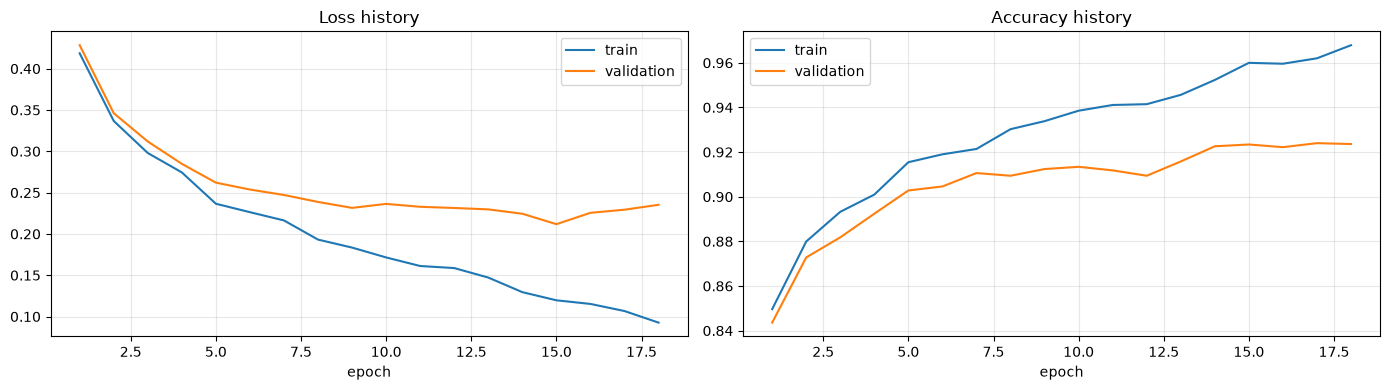

In [12]:
from IPython.display import display

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())

# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
def factorize_named_linear(model, layer_name, rank):
    """指定した Linear 層だけを rank の2層に置換したコピーを返す。

    ``Linear(in -> out)`` を ``Linear(in -> rank)`` + ``Linear(rank -> out)``
    に分解する。CNN なら ``layer_name="fc1"`` のように、SVDしたい層の
    属性名を文字列で渡す。

    元の model は変更しない。MNISTMLP は作らず、渡されたモデルをコピーする。
    """
    compressed_model = copy.deepcopy(model)
    layer = getattr(compressed_model, layer_name)
    setattr(
        compressed_model,
        layer_name,
        factorize_linear_layer(layer, rank),
    )
    return compressed_model


# 使い方:
# compressed_model = one_layer_svd_model(model, "fc1", rank=64)
# fc2 を圧縮したいとき:
# compressed_model = one_layer_svd_model(model, "fc2", rank=8)


In [14]:
def estimate_macs(model,fc1_rank, verbose=True):
    """現在の MLP と SVD 圧縮版の MACs・削減率を比較する。

    ``fc1`` と ``fc2`` は低ランク2層へ置換済み、``fc3`` は元の Linear
    のまま、という元Notebookと同じ前提で計算する。
    """
    baseline_macs = (
        linear_macs(model.fc1)
        + linear_macs(model.fc2)
    )

    compressed_macs = (
        compressed_linear_macs(model.fc1.weight.shape[0],model.fc1.weight.shape[1], fc1_rank)
        + linear_macs(model.fc2)
    )
    compute_reduction_rate = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline MACs:", baseline_macs)
        print("Compressed MACs:", compressed_macs)
        print(f"Compute reduction: {compute_reduction_rate:.2%}")

    return baseline_macs, compressed_macs, compute_reduction_rate

In [15]:
R1_LIST = [16,20,24,28,32,36,42,44,48,64,80,96,112,128]  # fc1 の rank 候補
#R2_LIST = [10]       # fc2 の rank 候補

#rank_configs = list(itertools.product(R1_LIST,R2_LIST))  # 【.ipynb】実験条件

# 【.py】metrics/model_comparison.py / metrics/mlp_macs.py
baseline_time_s = benchmark_inference(
    model,
    test_loader,
    device,
    warmup=20,    # 【.ipynb】ベンチ条件
    repeats=2000, # 【.ipynb】ベンチ条件
)
# 【.py】training/loops.py
baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)

rank_results = []
for fc1_rank in R1_LIST:
    
    compressed_model = factorize_named_linear(
        model,
        "fc1",
        fc1_rank,
    )

    validation_loss, validation_acc = evaluate(
        compressed_model,
        validation_loader_rank,
        criterion,
        device,
    )
    # 【.py】metrics/*
    drop = accuracy_drop(
        baseline_rank_validation_acc,
        validation_acc,
        verbose=False,
    )
    # 【.py】metrics/mlp_macs.py
    _, compressed_macs, compute_reduction = estimate_macs(
        model,
        fc1_rank,
        verbose=False,
    )
    compressed_time_s = benchmark_inference(
        compressed_model,
        validation_loader_rank,
        device,
        warmup=5,
        repeats=200,
    )

    # 【.ipynb側】どの列を結果表に入れるかは実験設計
    row = {
        "fc1_rank": fc1_rank,
        "parameters": count_parameters(compressed_model),
        "parameters_reduction": parameters_reduction(model, compressed_model),
        "validation_loss": validation_loss,
        "validation_acc": validation_acc,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        "agreement": agreement(model, compressed_model, validation_loader_rank, device),
        "logits_rmse": logits_rmse(model, compressed_model, validation_loader_rank, device),
        "retained_energy_fc1": retained_energy(model.fc1, fc1_rank),
        "model": compressed_model,
    }
    rank_results.append(row)
    print(
        f"r1={fc1_rank:3d}| "
        f"Acc={validation_acc:.4f} loss={validation_loss:.4f} | "
        f"params={row['parameters']} MACs={compressed_macs} | "
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(rank_results)} 件")

r1= 16| Acc=0.8942 loss=0.3033 | params=72458 MACs=53504 | agreement=0.9258
r1= 20| Acc=0.9142 loss=0.2503 | params=85514 MACs=66560 | agreement=0.9568
r1= 24| Acc=0.9172 loss=0.2334 | params=98570 MACs=79616 | agreement=0.9754
r1= 28| Acc=0.9166 loss=0.2311 | params=111626 MACs=92672 | agreement=0.9736
r1= 32| Acc=0.9212 loss=0.2231 | params=124682 MACs=105728 | agreement=0.9836
r1= 36| Acc=0.9228 loss=0.2206 | params=137738 MACs=118784 | agreement=0.9860
r1= 42| Acc=0.9250 loss=0.2191 | params=157322 MACs=138368 | agreement=0.9916
r1= 44| Acc=0.9244 loss=0.2178 | params=163850 MACs=144896 | agreement=0.9918
r1= 48| Acc=0.9252 loss=0.2179 | params=176906 MACs=157952 | agreement=0.9940
r1= 64| Acc=0.9252 loss=0.2163 | params=229130 MACs=210176 | agreement=0.9964
r1= 80| Acc=0.9254 loss=0.2156 | params=281354 MACs=262400 | agreement=0.9992
r1= 96| Acc=0.9260 loss=0.2156 | params=333578 MACs=314624 | agreement=0.9994
r1=112| Acc=0.9256 loss=0.2156 | params=385802 MACs=366848 | agreement=

pareto points: 10


,fc1_rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,16,72458,0.303260,0.00000,1.000000
1,20,85514,0.250269,0.06250,0.395690
2,24,98570,0.233418,0.12500,0.203523
3,28,111626,0.231134,0.18750,0.177472
4,32,124682,0.223103,0.25000,0.085889
5,36,137738,0.220645,0.31250,0.057857
6,42,157322,0.219102,0.40625,0.040260
7,44,163850,0.217802,0.43750,0.025434
8,64,229130,0.216347,0.75000,0.008839
9,80,281354,0.215572,1.00000,0.000000


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\rank_sweep_results.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\pareto_frontier.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\parameters_vs_validation_loss_normalize.png


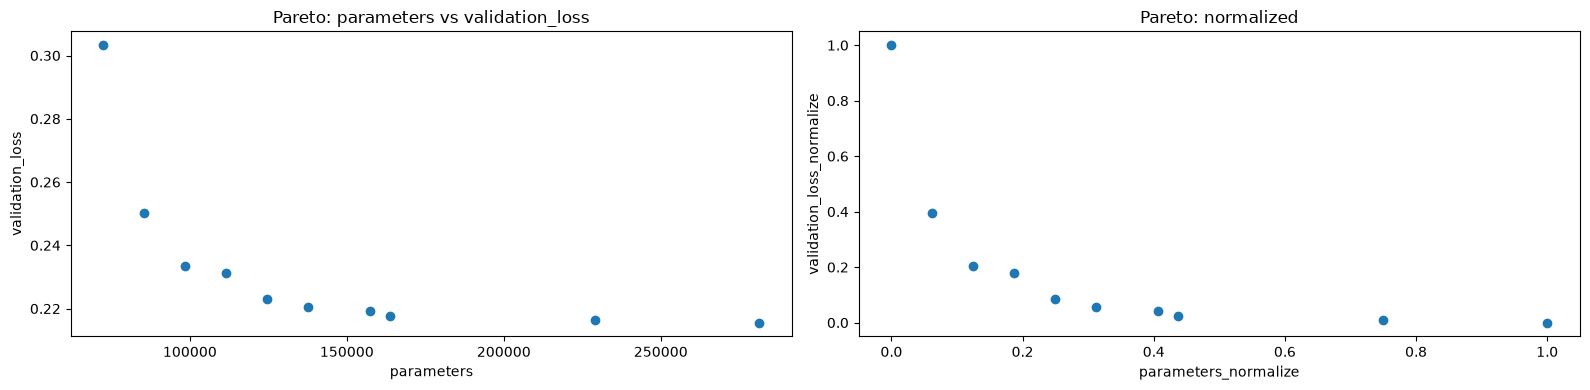

In [16]:
# ============================================================
# 【.ipynb側】前処理フィルタ・正規化・プロット
# 【.py側】Pareto frontier抽出だけ extract_pareto_frontier に任せる
# 元03では dominated判定の for ループをNotebook内に書いていた
# ============================================================
baseline_params = count_parameters(model)  # 【.py】metrics/model_comparison.py
df_rank_results = pd.DataFrame(rank_results)

# 【.ipynb側】「baselineより大きいparamsを落とす」等は実験判断
df_pareto_input = df_rank_results[
    (df_rank_results["parameters"] <= baseline_params)
    & (df_rank_results["compute_reduction"] > 0)
].copy()

# 【.py】selection/pareto.py
# 両目的とも小さいほど良い場合の非劣後点を返す
df_pareto_view = extract_pareto_frontier(
    df_pareto_input,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】どの列を正規化するかは実験設計
scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# 【.ipynb側】可視化
fig_pareto, axes_pareto = plt.subplots(1, 2, figsize=(16, 4))
axes_pareto[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
)
axes_pareto[0].set_xlabel("parameters")
axes_pareto[0].set_ylabel("validation_loss")
axes_pareto[0].set_title("Pareto: parameters vs validation_loss")

axes_pareto[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
)
axes_pareto[1].set_xlabel("parameters_normalize")
axes_pareto[1].set_ylabel("validation_loss_normalize")
axes_pareto[1].set_title("Pareto: normalized")
plt.tight_layout()

print("pareto points:", len(df_pareto_view))
display(
    df_pareto_view[
        [
            "fc1_rank",
            "parameters",
            "validation_loss",
            "parameters_normalize",
            "validation_loss_normalize",
        ]
    ]
)

# 【.py】results_dir は get_experiment_dirs（utils/paths.py）
# 【.ipynb側】ファイル名と「model列はCSVに書かない」は実験判断
# MLP 02 と同じ成果物名で、このセルの結果を保存する
results_dir.mkdir(parents=True, exist_ok=True)
rank_sweep_path = results_dir / "rank_sweep_results.csv"
pareto_path = results_dir / "pareto_frontier.csv"
pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"

df_rank_results.drop(columns=["model"], errors="ignore").to_csv(
    rank_sweep_path,
    index=False,
)
df_pareto_view.drop(columns=["model"], errors="ignore").to_csv(
    pareto_path,
    index=False,
)
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")

print("saved:", rank_sweep_path)
print("saved:", pareto_path)
print("saved:", pareto_figure_path)
plt.show()


In [17]:
# ============================================================
# 【.py】get_first_point / line_equation / find_knee_point
# 元03の GetPoint / GetlinearEquation / GetKneePoint_loop を
# Python標準の snake_case 名へ整理して移植
# 【.ipynb側】knee±1を候補にする、という実験判断はここに残す
# ============================================================

# 【.py】selection/knee.py
# get_first_point: 指定列でソートした先頭点の座標を返す
p0 = get_first_point(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
p1 = get_first_point(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

# 端点を結ぶ直線から最も遠い点が knee
knee_point, knee_distance = find_knee_point(
    df_pareto_view,
    *line_equation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)

# 【.ipynb側】kneeの前後1点もFine-tuning候補にする
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)
knee_mask = (
    (df_pareto_view["parameters_normalize"] == knee_point[0])
    & (df_pareto_view["validation_loss_normalize"] == knee_point[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print("knee distance:", knee_distance)
print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}]")
print("knee:")
display(df_pareto_knee.drop(columns="model"))
print("knee ±1:")
display(df_pareto_best.drop(columns="model"))

knee distance: 0.47480583710942986
knee_pos=2, neighbors iloc[1:4]
knee:


,fc1_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,parameters_normalize,validation_loss_normalize
2,24,98570,0.766223,0.233418,0.9172,0.0082,79616,0.802289,0.703602,0.82849,0.9754,0.855327,0.856742,0.125,0.203523


knee ±1:


,fc1_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,parameters_normalize,validation_loss_normalize
1,20,85514,0.797188,0.250269,0.9142,0.0112,66560,0.834711,0.703602,0.931188,0.9568,1.347940,0.827196,0.0625,0.395690
2,24,98570,0.766223,0.233418,0.9172,0.0082,79616,0.802289,0.703602,0.828490,0.9754,0.855327,0.856742,0.1250,0.203523
3,28,111626,0.735259,0.231134,0.9166,0.0088,92672,0.769866,0.703602,0.819487,0.9736,0.723372,0.877729,0.1875,0.177472


In [18]:
# ============================================================
# 【.ipynb側】どの候補をFine-tuningするか、候補ごとの seed / optimizer
# 【.py側】学習ループ本体は fit_with_early_stopping を再利用
# 元03では for re_epoch in range(MAX_EPOCHS): を直書きしていた
# ============================================================
set_seed(SEED)
fine_tuned_records = []
LEARNING_RATE=1e-3
MAX_EPOCHS = 30

for _, pareto_row in df_pareto_best.iterrows():
    fc1_rank = int(pareto_row["fc1_rank"])
    fine_tuned_model = copy.deepcopy(pareto_row["model"]).to(device)

    # 【.ipynb側】候補ごとに optimizer を作り直す（元03と同じ注意点）
    candidate_optimizer = torch.optim.Adam(
        fine_tuned_model.parameters(),
        lr=LEARNING_RATE,
    )
    # 【.ipynb側】候補ごとの再現可能な別シード（元03と同じ規則）
    set_seed(SEED + 1000 * fc1_rank )
    print(f"\n=== fine-tune r1={fc1_rank} ===")

    # 【.py】training/fit.py を baseline 学習と同じく再利用
    fit_result = fit_with_early_stopping(
        model=fine_tuned_model,
        train_loader=train_loader,
        val_loader=validation_loader_early_stop,  # Early Stopping用（rank用ではない）
        criterion=criterion,
        optimizer=candidate_optimizer,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    fine_tuned_records.append(
        {
            "fc1_rank": fc1_rank,
            "best_epoch": fit_result["best_epoch"],
            "best_validation_loss": fit_result["best_validation_loss"],
            "history": fit_result["history"],
            "model": fit_result["model"],
        }
    )

df_fine_tuned_models = pd.DataFrame(fine_tuned_records)
display(df_fine_tuned_models.drop(columns=["history", "model"]))


=== fine-tune r1=20 ===
Early stopping at epoch 5

=== fine-tune r1=24 ===
Early stopping at epoch 6

=== fine-tune r1=28 ===
Early stopping at epoch 6


,fc1_rank,best_epoch,best_validation_loss
0,20,2,0.229169
1,24,3,0.216741
2,28,3,0.228242


## 結果の保存

学習履歴の CSV は fit セルで `fit_history.csv` / `fit_loss_history.csv` として保存済み。

ここからは MLP の rank selection と同じく、knee で選んだ rank と前後点、圧縮モデルの重みを残す。

- `selected_rank.csv` … knee 本体 1 行
- `selected_rank_neighbors.csv` … knee ±1
- `models/.../r1-{rank}_{tag}.pt` … 圧縮後の Linear 層を含む重み


In [19]:
# ============================================================
# 【.ipynb側】何をどのファイル名で残すか（実験固有）
# 【.py側】results_dir / models_dir は get_experiment_dirs が用意済み
# ------------------------------------------------------------
# CSV（model 列は PyTorch オブジェクトなので保存しない）
#   selected_rank.csv            … knee で選ばれた rank
#   selected_rank_neighbors.csv  … knee ±1
# あわせて圧縮モデルの重みも保存
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


def _drop_model_col(df):
    """CSV 向けに model 列を除いたコピーを返す"""
    return df.drop(columns=["model"], errors="ignore")


selected_path = results_dir / "selected_rank.csv"
neighbors_path = results_dir / "selected_rank_neighbors.csv"

# Pareto セルでも保存するが、knee 後の列（正規化済み）で上書きして揃える
_drop_model_col(df_rank_results).to_csv(
    results_dir / "rank_sweep_results.csv",
    index=False,
)
_drop_model_col(df_pareto_view).to_csv(
    results_dir / "pareto_frontier.csv",
    index=False,
)

# knee 本体 1 行（前後込みの df_pareto_best ではない）
_drop_model_col(df_pareto_knee).to_csv(selected_path, index=False)
_drop_model_col(df_pareto_best).to_csv(neighbors_path, index=False)

# --- 圧縮モデルの重み（knee ±1 = df_pareto_best）---
# CNN 02 は fc1 のみなので r2 はファイル名に含めない
saved_model_paths = []
for idx, row in df_pareto_best.iterrows():
    if idx < knee_pos:
        tag = "prev"
    elif idx > knee_pos:
        tag = "next"
    else:
        tag = "knee"

    r1 = int(row["fc1_rank"])
    model_path = models_dir / f"r1-{r1}_{tag}.pt"
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")

print(f"saved selected:   {selected_path}")
print(f"saved neighbors:  {neighbors_path}")
print(f"saved figure:     {pareto_figure_path}")
for path in saved_model_paths:
    print(f"saved model:      {path}")


saved selected:   D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\selected_rank.csv
saved neighbors:  D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\selected_rank_neighbors.csv
saved figure:     D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\parameters_vs_validation_loss_normalize.png
saved model:      D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_cnn_linear_svd\r1-20_prev.pt
saved model:      D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_cnn_linear_svd\r1-24_knee.pt
saved model:      D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\02_cnn_linear_svd\r1-28_next.pt


In [20]:
# 学習履歴 CSV は fit セルで保存済み
#   results/.../02_cnn_linear_svd/fit_history.csv
#   results/.../02_cnn_linear_svd/fit_loss_history.csv
print("fit history already saved:", csv_dir / "fit_history.csv")
print("fit loss history already saved:", csv_dir / "fit_loss_history.csv")


fit history already saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\fit_history.csv
fit loss history already saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\02_cnn_linear_svd\fit_loss_history.csv
